##解压图片

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!cp /content/drive/MyDrive/24stu/肝败下风/* ./

In [3]:
!unrar x /content/新建文件夹.rar


UNRAR 6.11 beta 1 freeware      Copyright (c) 1993-2022 Alexander Roshal


Extracting from /content/新建文件夹.rar

Creating    新建文件夹                                                     OK
Extracting  新建文件夹/1.jpeg                                                   0%  OK 
Extracting  新建文件夹/10.jpg                                                   0%  OK 
Extracting  新建文件夹/100.jpg                                                  0%  OK 
Extracting  新建文件夹/101.jpg                                                  1%  OK 
Extracting  新建文件夹/102.jpg                                                  1%  OK 
Extracting  新建文件夹/103.jpg                                                  1%  OK 
Extracting  新建文件夹/104.jpg                                                  1%  OK 
Extracting  新建文件夹/105.jpg                                                  1%  OK 
Extracting  新建文件夹/106.jpg                                                  

# 导入python包

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import os
from PIL import Image
import seaborn as sns

from tokenizers import Tokenizer
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn import metrics
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

from torch.utils.data import Dataset
from torch.utils.data import DataLoader
import torch
from torch import nn
from torch.nn import  functional as F

from torchvision.io import read_image
from torchvision import datasets
from torchvision.transforms import ToTensor
from torchvision import transforms
import torchvision


from torchvision import datasets,models

from transformers import AutoTokenizer, AutoModelForSequenceClassification

# 超参数定义

In [2]:

max_len = 40
n_class = 4
train_num = 160
test_num = 40

# 准备数据集

## 生成训练集和测试集

In [3]:
def get_pic_name(item):
  pic_name = item.split('/')[-1]
  pic_path = '/content/新建文件夹/'+pic_name
  return pic_path

In [4]:
import json
import re

def get_num_list(json_str):
  # json_str = "{'score': [0.1, 0.7, 0.2]}"
  ori_list = json_str.split('[')[1].split(']')[0].split(',')
  num_list = [float(item) for item in ori_list]
  return num_list



In [5]:
pd_all = pd.read_csv('/content/新建文件夹/加了score值的表格.csv').sample(frac=1).reset_index(drop=True)
pd_all['label'] = pd_all['label'] - 1
pd_all['pic_path'] = pd_all['pic'].map(get_pic_name)
pd_all['vec'] = pd_all.score.map(get_num_list)
pd_train = pd_all[:160]
pd_test = pd_all[160:]
pd_all

,Unnamed: 0,pic,label,text,score,pic_path,vec
0,1,/content/1.jpeg,0,图中金发碧眼的女子身穿黑色紧身背心，棕色短裤，手持一支黑色的突击步枪，腰间佩戴着子弹带，作...,"{'score': [0.1, 0.7, 0.2]}",/content/新建文件夹/1.jpeg,"[0.1, 0.7, 0.2]"
1,44,/content/44.jpg,0,这是一张一个特警拿着枪的图片，他身穿黑色特警服，戴着头盔和面罩，腰间别着手枪，手持冲锋枪，...,"{'score': [0.1, 0.7, 0.2]}",/content/新建文件夹/44.jpg,"[0.1, 0.7, 0.2]"
2,181,/content/181.jpg,3,图中展示了两辆汽车相撞的场景。一辆白色的汽车飞了起来，另一辆绿色的汽车被压在下面。汽车的零...,"\n {'score': [0.1, 0.3, 0.6]}\n",/content/新建文件夹/181.jpg,"[0.1, 0.3, 0.6]"
3,156,/content/156.jpg,3,一辆银白色的面包车和一辆蓝色的货车在公路上发生了严重的交通事故，面包车车头严重变形，几乎被...,"{'score': [0.05, 0.05, 0.9]}",/content/新建文件夹/156.jpg,"[0.05, 0.05, 0.9]"
4,18,/content/18.jpg,0,这是一张枪支的图片。桌子上有五支枪，其中有三支是长枪，两支是手枪。长枪中有一支,"{'score': [0.1, 0.2, 0.7]}",/content/新建文件夹/18.jpg,"[0.1, 0.2, 0.7]"
...,...,...,...,...,...,...,...
195,5,/content/5.jpg,0,这张图片展示了一把银色的手枪，枪口朝向前方。一个成年男子的手握住枪柄，他的手指扣在扳机护圈上。,"{'score': [0.1, 0.7, 0.2]}",/content/新建文件夹/5.jpg,"[0.1, 0.7, 0.2]"
196,34,/content/34.jpg,0,这是一张枪支的图片。桌子上摆放着五把枪，枪的后面有一面美国国旗。,"{'score': [0.1, 0.3, 0.6]}",/content/新建文件夹/34.jpg,"[0.1, 0.3, 0.6]"
197,63,/content/63.jpg,1,图片显示了一个蒙面歹徒，他身穿深色衣服，戴着头套，只露出眼睛。他右手持刀，刀尖朝向前方，左...,"{'score': [0.1,0.7,0.2]}",/content/新建文件夹/63.jpg,"[0.1, 0.7, 0.2]"
198,151,/content/151.jpg,3,一辆公交车和一辆小轿车在马路上发生了严重的交通事故。公交车的车头和轿车的车尾严重损毁，公交...,"{'score': [0.2, 0.3, 0.5]}",/content/新建文件夹/151.jpg,"[0.2, 0.3, 0.5]"


In [6]:
# pd_all = pd.read_csv('/content/数据集/data.csv',encoding='gbk').sample(frac=1).reset_index(drop=True)
# pd_all['pic_path'] = pd_all['pic'].map(get_pic_name)
# pd_all['vec'] = [[0.5,0.1,0.4]]*len(pd_all)
# pd_train = pd_all[:160]
# pd_test = pd_all[160:]
# pd_all

## 查看图文特征

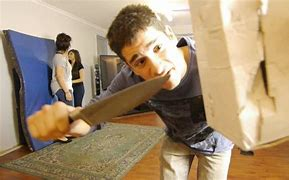

In [7]:

eg_pic_path = '/content/新建文件夹/91.jpg'
# eg_pic_path = img_dir + '16_05_01_100.jpg'
# 打开图像并加载
img = Image.open(eg_pic_path)
# 显示图像
img

In [8]:
def get_len(item):
  sen_len = len(item.split(' '))
  return sen_len

In [9]:
pd_train['len'] = pd_train['text'].map(len)
pd_test['len'] = pd_test['text'].map(len)
pd_train

/tmp/ipython-input-9-2928987940.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  pd_train['len'] = pd_train['text'].map(len)
/tmp/ipython-input-9-2928987940.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  pd_test['len'] = pd_test['text'].map(len)


,Unnamed: 0,pic,label,text,score,pic_path,vec,len
0,1,/content/1.jpeg,0,图中金发碧眼的女子身穿黑色紧身背心，棕色短裤，手持一支黑色的突击步枪，腰间佩戴着子弹带，作...,"{'score': [0.1, 0.7, 0.2]}",/content/新建文件夹/1.jpeg,"[0.1, 0.7, 0.2]",62
1,44,/content/44.jpg,0,这是一张一个特警拿着枪的图片，他身穿黑色特警服，戴着头盔和面罩，腰间别着手枪，手持冲锋枪，...,"{'score': [0.1, 0.7, 0.2]}",/content/新建文件夹/44.jpg,"[0.1, 0.7, 0.2]",67
2,181,/content/181.jpg,3,图中展示了两辆汽车相撞的场景。一辆白色的汽车飞了起来，另一辆绿色的汽车被压在下面。汽车的零...,"\n {'score': [0.1, 0.3, 0.6]}\n",/content/新建文件夹/181.jpg,"[0.1, 0.3, 0.6]",60
3,156,/content/156.jpg,3,一辆银白色的面包车和一辆蓝色的货车在公路上发生了严重的交通事故，面包车车头严重变形，几乎被...,"{'score': [0.05, 0.05, 0.9]}",/content/新建文件夹/156.jpg,"[0.05, 0.05, 0.9]",98
4,18,/content/18.jpg,0,这是一张枪支的图片。桌子上有五支枪，其中有三支是长枪，两支是手枪。长枪中有一支,"{'score': [0.1, 0.2, 0.7]}",/content/新建文件夹/18.jpg,"[0.1, 0.2, 0.7]",40
...,...,...,...,...,...,...,...,...
155,71,/content/71.jpg,1,图片中有一把刀，刀柄是黑色的，刀鞘是棕色的。刀柄上有一个金属製の护手，刀刃是银色的，非常锋...,"{'score': [0.1, 0.7, 0.2]}",/content/新建文件夹/71.jpg,"[0.1, 0.7, 0.2]",66
156,152,/content/152.jpg,3,一辆红色的货车和一辆黑色的轿车在公路上发生了交通事故。货车停在路边，轿车停在货车前面，两辆...,"{'score': [0.1, 0.7, 0.2]}",/content/新建文件夹/152.jpg,"[0.1, 0.7, 0.2]",104
157,171,/content/171.jpg,3,这是一起惨烈的交通事故，一辆红色的大货车和一辆蓝色的小货车相撞，小货车被大货车压在车头下面...,"{'score': [0.05, 0.01, 0.94]}",/content/新建文件夹/171.jpg,"[0.05, 0.01, 0.94]",91
158,51,/content/51.jpg,1,图中是一个蒙面男子，身穿深色衣服，手持一把刀，眼神凶狠地看着前方，似乎随时准备攻击。他可能...,"{‘score’: [0.1,0.3,0.6 ]}",/content/新建文件夹/51.jpg,"[0.1, 0.3, 0.6]",63


<Axes: >

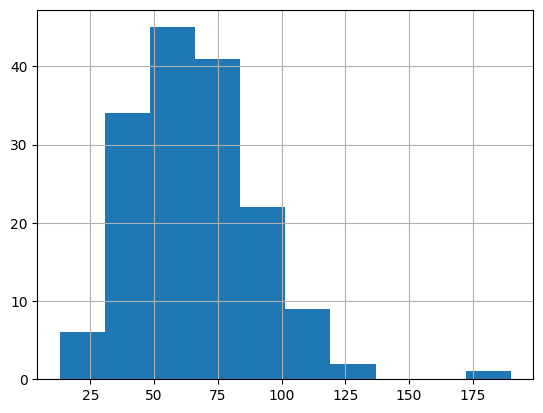

In [10]:

pd_train['len'].hist()

In [11]:
pd_train['label'].value_counts()

,count
label,
0,41
3,40
2,40
1,39


In [12]:
pd_test['label'].value_counts()

,count
label,
1,11
3,10
2,10
0,9


# 确定GPU cpu使用情况

In [13]:
# Get cpu or gpu device for training.
device = "cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu"
print(f"Using {device} device")

Using cuda device


# Gemini-scene模型： vit + bert + clip + att

## 准备训练和测试循环

In [14]:
def train(dataloader, model, loss_fn, optimizer):
    size = len(dataloader.dataset)
    model.train()
    for batch, (x_img,x_img_clip, x_text,x_text_clip, x_vec, y) in enumerate(dataloader):

        x_img, x_text, y = x_img.to(device),x_text.to(device), y.to(device)
        x_img_clip,x_text_clip = x_img_clip.to(device),x_text_clip.to(device)
        x_vec = x_vec.to(device)
        pred = model(x_img,x_img_clip, x_text,x_text_clip, x_vec)
        loss = loss_fn(pred, y)

        # Backpropagation
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        if batch % 30 == 0:
            loss, current = loss.item(), batch * len(x_img)
            print(f"loss: {loss:>7f}  [{current:>5d}/{size:>5d}]")

In [15]:
def test(dataloader, model, loss_fn):
    size = len(dataloader.dataset)
    num_batches = len(dataloader)
    model.eval()
    test_loss, correct = 0, 0
    with torch.no_grad():
        for batch, (x_img,x_img_clip, x_text,x_text_clip, x_vec,  y) in enumerate(dataloader):
            x_img, x_text, y = x_img.to(device),x_text.to(device), y.to(device)
            x_img_clip,x_text_clip = x_img_clip.to(device),x_text_clip.to(device)
            x_vec = x_vec.to(device)
            pred = model(x_img,x_img_clip, x_text,x_text_clip, x_vec)
            test_loss += loss_fn(pred, y).item()
            correct += (pred.argmax(1) == y).type(torch.float).sum().item()
    test_loss /= num_batches
    correct /= size
    print(f"Test Error: \n Accuracy: {(100*correct):>0.1f}%, Avg loss: {test_loss:>8f} \n")
    return test_loss, correct

## 数据处理和特征工程

### 英文编码tokenizer roberta

In [16]:
model_name = "bert-base-chinese"
tokenizer_bert = AutoTokenizer.from_pretrained(model_name)

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


In [17]:
eg_text = '早上好'
eg_result = tokenizer_bert(eg_text, padding='max_length', max_length=25, truncation=True, return_tensors="pt")
eg_result

{'input_ids': tensor([[ 101, 3193,  677, 1962,  102,    0,    0,    0,    0,    0,    0,    0,
            0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
            0]]), 'token_type_ids': tensor([[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0]]), 'attention_mask': tensor([[1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0]])}

In [18]:
voc_size = tokenizer_bert.vocab_size
voc_size

21128

### clip 文本处理

In [19]:
from transformers import AutoTokenizer, CLIPTextModelWithProjection

t_clip_model = CLIPTextModelWithProjection.from_pretrained("openai/clip-vit-base-patch32")
t_clip_tokenizer = AutoTokenizer.from_pretrained("openai/clip-vit-base-patch32")

# inputs = t_clip_tokenizer(["a photo of a cat", "a photo of a dog"],  return_tensors="pt",max_length=50,padding="max_length",truncation=True)
inputs = t_clip_tokenizer("a photo of a cat",  return_tensors="pt",max_length=50,padding="max_length",truncation=True)

outputs = t_clip_model(**inputs)
text_embeds = outputs.text_embeds

In [20]:
text_embeds.shape

torch.Size([1, 512])

In [21]:
inputs

{'input_ids': tensor([[49406,   320,  1125,   539,   320,  2368, 49407, 49407, 49407, 49407,
         49407, 49407, 49407, 49407, 49407, 49407, 49407, 49407, 49407, 49407,
         49407, 49407, 49407, 49407, 49407, 49407, 49407, 49407, 49407, 49407,
         49407, 49407, 49407, 49407, 49407, 49407, 49407, 49407, 49407, 49407,
         49407, 49407, 49407, 49407, 49407, 49407, 49407, 49407, 49407, 49407]]), 'attention_mask': tensor([[1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0]])}

In [22]:
t_clip_model(inputs.input_ids).text_embeds

tensor([[ 1.5546e-01,  7.3294e-02, -2.4484e-01, -2.2115e-01, -1.9344e-01,
          2.0518e-01, -3.1749e-01, -7.8242e-01, -1.8164e-01,  1.9433e-01,
         -7.6181e-02, -6.0524e-01,  1.9231e-01, -1.0163e-01,  1.3738e-01,
          1.3672e-01,  2.4225e-01, -1.7962e-01, -8.8909e-02,  2.8717e-01,
          6.3450e-01,  1.6426e-01,  4.5428e-01, -2.9290e-02, -2.5141e-01,
          1.9239e-01,  2.4865e-01,  6.4663e-01, -2.3520e-01, -2.3172e-01,
          2.2597e-01,  1.8951e-01,  1.5041e-01,  4.8223e-01, -2.1912e-01,
         -1.8246e-01,  2.5335e-01, -2.7369e-02,  2.3673e-01,  2.3743e-01,
         -9.5580e-02, -1.1553e-01,  2.8116e-01,  1.1927e-01,  1.6268e-01,
          8.6734e-02, -2.5180e-01,  3.1935e-02, -5.3379e-02, -1.6613e-01,
          8.5413e-02, -4.0280e-02,  5.2349e-01, -9.5650e-02, -5.3954e-02,
         -2.9765e-01,  4.7326e-02,  2.0898e-01, -5.6442e-02, -3.0747e-02,
          4.5797e-01, -1.1969e-01, -2.9258e-01,  6.0592e-02,  2.1891e-01,
         -2.1244e-01,  3.9416e-02,  2.

### clip 图像处理

In [23]:
from PIL import Image
import requests
from transformers import AutoProcessor, CLIPVisionModelWithProjection

img_clip_model = CLIPVisionModelWithProjection.from_pretrained("openai/clip-vit-base-patch32")
img_clip_processor = AutoProcessor.from_pretrained("openai/clip-vit-base-patch32")

url = "http://images.cocodataset.org/val2017/000000039769.jpg"
image = Image.open(requests.get(url, stream=True).raw)

inputs = img_clip_processor(images=image, return_tensors="pt")

outputs = img_clip_model(**inputs)
image_embeds = outputs.image_embeds

Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


In [24]:
inputs.pixel_values.shape

torch.Size([1, 3, 224, 224])

In [25]:
outputs.image_embeds.shape

torch.Size([1, 512])

In [26]:
pd_all.head()

,Unnamed: 0,pic,label,text,score,pic_path,vec
0,1,/content/1.jpeg,0,图中金发碧眼的女子身穿黑色紧身背心，棕色短裤，手持一支黑色的突击步枪，腰间佩戴着子弹带，作...,"{'score': [0.1, 0.7, 0.2]}",/content/新建文件夹/1.jpeg,"[0.1, 0.7, 0.2]"
1,44,/content/44.jpg,0,这是一张一个特警拿着枪的图片，他身穿黑色特警服，戴着头盔和面罩，腰间别着手枪，手持冲锋枪，...,"{'score': [0.1, 0.7, 0.2]}",/content/新建文件夹/44.jpg,"[0.1, 0.7, 0.2]"
2,181,/content/181.jpg,3,图中展示了两辆汽车相撞的场景。一辆白色的汽车飞了起来，另一辆绿色的汽车被压在下面。汽车的零...,"\n {'score': [0.1, 0.3, 0.6]}\n",/content/新建文件夹/181.jpg,"[0.1, 0.3, 0.6]"
3,156,/content/156.jpg,3,一辆银白色的面包车和一辆蓝色的货车在公路上发生了严重的交通事故，面包车车头严重变形，几乎被...,"{'score': [0.05, 0.05, 0.9]}",/content/新建文件夹/156.jpg,"[0.05, 0.05, 0.9]"
4,18,/content/18.jpg,0,这是一张枪支的图片。桌子上有五支枪，其中有三支是长枪，两支是手枪。长枪中有一支,"{'score': [0.1, 0.2, 0.7]}",/content/新建文件夹/18.jpg,"[0.1, 0.2, 0.7]"


### 准备dataset

In [27]:
class CustomDataset(Dataset):
    def __init__(self, pd_data,tokenizer_en):
        self.pd_data = pd_data
        self.text_list = list(pd_data['text'])
        self.label_list = list(pd_data['label'])
        self.img_path_list = list(pd_data['pic_path'])
        self.vec_lists = list(pd_data['vec'])
        self.tokenizer = tokenizer_en
        self.t_clip_tokenizer = t_clip_tokenizer
        self.img_clip_processor = img_clip_processor

    def __len__(self):
        return len(self.pd_data)

    def __getitem__(self, idx):


        # 文本数据处理
        one_text = self.text_list[idx]
        one_text_array = self.tokenizer(one_text, padding='max_length', max_length=max_len, truncation=True, return_tensors="pt")['input_ids'][0]
        one_clip_text = self.t_clip_tokenizer(one_text,  return_tensors="pt",max_length=max_len,padding="max_length",truncation=True)['input_ids'][0]


        # 图像数据处理
        one_path = self.img_path_list[idx]
        # one_path = img_dir + one_path
        img_tensor = read_image(one_path,mode=torchvision.io.ImageReadMode.RGB)
        img_tensor = transforms.Resize((224,224))(img_tensor).float()

        image = Image.open(one_path).convert("RGB")
        one_clip_img = img_clip_processor(images=image, return_tensors="pt").pixel_values[0]


        # 向量数据处理
        one_vec = self.vec_lists[idx]
        one_vec_tensor = torch.tensor(one_vec).float()


        # label数据处理
        one_label = self.label_list[idx]
        one_label = torch.tensor(one_label).long()
        return img_tensor, one_clip_img, one_text_array, one_clip_text, one_vec_tensor, one_label


tran_ds = CustomDataset(pd_train[:train_num],tokenizer_bert)
test_ds = CustomDataset(pd_test[:test_num],tokenizer_bert)

tran_ds[1][0].shape,tran_ds[1][1].shape,len(tran_ds),len(test_ds)

(torch.Size([3, 224, 224]), torch.Size([3, 224, 224]), 160, 40)

### 准备dataloader

In [28]:

train_dl = DataLoader(tran_ds, batch_size=10, shuffle=True)
test_dl = DataLoader(test_ds, batch_size=8)

In [29]:
len(test_dl.dataset)

40

In [30]:
for b_img,b_img_clip, b_text,b_text_clip,b_vec,label in test_dl:
  print(b_text.shape)
  print(b_img.shape)
  print(b_text_clip.shape)
  print(b_img_clip.shape)
  print(b_vec.shape)
  print(label)
  break

torch.Size([8, 40])
torch.Size([8, 3, 224, 224])
torch.Size([8, 40])
torch.Size([8, 3, 224, 224])
torch.Size([8, 3])
tensor([3, 2, 1, 2, 1, 2, 2, 2])


In [31]:
b_vec

tensor([[0.2000, 0.3000, 0.5000],
        [0.1000, 0.7000, 0.2000],
        [0.2000, 0.6000, 0.2000],
        [0.1000, 0.8000, 0.1000],
        [0.1000, 0.3000, 0.6000],
        [0.1000, 0.7000, 0.2000],
        [0.1000, 0.7000, 0.2000],
        [0.1000, 0.2000, 0.7000]])

## 模型构建

### vit模块

In [32]:
class Image_vit(nn.Module):
    def __init__(self):
        super().__init__()
        self.base_model_vit = models.vit_b_16(pretrained=True)
        self.base_model_vit.heads.head = nn.Linear(768, 100)

    def forward(self, x):
        x = self.base_model_vit(x)
        return x

vit_block = Image_vit().to(device)
# print(img_block)
vit_block(b_img.to(device)).shape

/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ViT_B_16_Weights.IMAGENET1K_V1`. You can also use `weights=ViT_B_16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


torch.Size([8, 100])

### 文本数据处理

In [33]:
class textBert(nn.Module):
    def __init__(self,):
        super().__init__()
        self.model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=100).to(device)

    def forward(self, x):
        x = self.model(x)
        return x.logits
text_bert = textBert().to(device)

text_bert(b_text.to(device)).shape

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-chinese and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


torch.Size([8, 100])

### 结构化数据处理

In [34]:
class vecBlock(nn.Module):
    def __init__(self):
        super().__init__()

        self.fc1 = nn.Linear(3, 120)
        self.fc2 = nn.Linear(120, 100)

    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        return x


vec_block = vecBlock().to(device)
print(vec_block)
vec_block(b_vec.to(device)).shape

vecBlock(
  (fc1): Linear(in_features=3, out_features=120, bias=True)
  (fc2): Linear(in_features=120, out_features=100, bias=True)
)


torch.Size([8, 100])

### 测试原始mamba模块输入输出

In [35]:
!uv pip install mamba-ssm --no-build-isolation > install_log.txt 2>&1

In [ ]:
# Copyright (c) 2023, Tri Dao, Albert Gu.

import math
from typing import Optional

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch import Tensor

from einops import rearrange, repeat

from mamba_ssm.ops.selective_scan_interface import selective_scan_fn, mamba_inner_fn

try:
    from causal_conv1d import causal_conv1d_fn, causal_conv1d_update
except ImportError:
    causal_conv1d_fn, causal_conv1d_update = None, None

try:
    from mamba_ssm.ops.triton.selective_state_update import selective_state_update
except ImportError:
    selective_state_update = None

try:
    from mamba_ssm.ops.triton.layer_norm import RMSNorm, layer_norm_fn, rms_norm_fn
except ImportError:
    RMSNorm, layer_norm_fn, rms_norm_fn = None, None, None


class Mamba(nn.Module):
    def __init__(
        self,
        d_model,
        d_state=16,
        d_conv=4,
        expand=2,
        dt_rank="auto",
        dt_min=0.001,
        dt_max=0.1,
        dt_init="random",
        dt_scale=1.0,
        dt_init_floor=1e-4,
        conv_bias=True,
        bias=False,
        use_fast_path=True,  # Fused kernel options
        layer_idx=None,
        device=None,
        dtype=None,
    ):
        factory_kwargs = {"device": device, "dtype": dtype}
        super().__init__()
        self.d_model = d_model
        self.d_state = d_state
        self.d_conv = d_conv
        self.expand = expand
        self.d_inner = int(self.expand * self.d_model)
        self.dt_rank = math.ceil(self.d_model / 16) if dt_rank == "auto" else dt_rank
        self.use_fast_path = use_fast_path
        self.layer_idx = layer_idx

        self.in_proj = nn.Linear(self.d_model, self.d_inner * 2, bias=bias, **factory_kwargs)

        self.conv1d = nn.Conv1d(
            in_channels=self.d_inner,
            out_channels=self.d_inner,
            bias=conv_bias,
            kernel_size=d_conv,
            groups=self.d_inner,
            padding=d_conv - 1,
            **factory_kwargs,
        )

        self.activation = "silu"
        self.act = nn.SiLU()

        self.x_proj = nn.Linear(
            self.d_inner, self.dt_rank + self.d_state * 2, bias=False, **factory_kwargs
        )
        self.dt_proj = nn.Linear(self.dt_rank, self.d_inner, bias=True, **factory_kwargs)

        # Initialize special dt projection to preserve variance at initialization
        dt_init_std = self.dt_rank**-0.5 * dt_scale
        if dt_init == "constant":
            nn.init.constant_(self.dt_proj.weight, dt_init_std)
        elif dt_init == "random":
            nn.init.uniform_(self.dt_proj.weight, -dt_init_std, dt_init_std)
        else:
            raise NotImplementedError

        # Initialize dt bias so that F.softplus(dt_bias) is between dt_min and dt_max
        dt = torch.exp(
            torch.rand(self.d_inner, **factory_kwargs) * (math.log(dt_max) - math.log(dt_min))
            + math.log(dt_min)
        ).clamp(min=dt_init_floor)
        # Inverse of softplus: https://github.com/pytorch/pytorch/issues/72759
        inv_dt = dt + torch.log(-torch.expm1(-dt))
        with torch.no_grad():
            self.dt_proj.bias.copy_(inv_dt)
        # Our initialization would set all Linear.bias to zero, need to mark this one as _no_reinit
        self.dt_proj.bias._no_reinit = True

        # S4D real initialization
        A = repeat(
            torch.arange(1, self.d_state + 1, dtype=torch.float32, device=device),
            "n -> d n",
            d=self.d_inner,
        ).contiguous()
        A_log = torch.log(A)  # Keep A_log in fp32
        self.A_log = nn.Parameter(A_log)
        self.A_log._no_weight_decay = True

        # D "skip" parameter
        self.D = nn.Parameter(torch.ones(self.d_inner, device=device))  # Keep in fp32
        self.D._no_weight_decay = True

        self.out_proj = nn.Linear(self.d_inner, self.d_model, bias=bias, **factory_kwargs)

    def forward(self, hidden_states, inference_params=None):
        """
        hidden_states: (B, L, D)
        Returns: same shape as hidden_states
        """
        batch, seqlen, dim = hidden_states.shape

        conv_state, ssm_state = None, None
        if inference_params is not None:
            conv_state, ssm_state = self._get_states_from_cache(inference_params, batch)
            if inference_params.seqlen_offset > 0:
                # The states are updated inplace
                out, _, _ = self.step(hidden_states, conv_state, ssm_state)
                return out

        # We do matmul and transpose BLH -> HBL at the same time
        xz = rearrange(
            self.in_proj.weight @ rearrange(hidden_states, "b l d -> d (b l)"),
            "d (b l) -> b d l",
            l=seqlen,
        )
        if self.in_proj.bias is not None:
            xz = xz + rearrange(self.in_proj.bias.to(dtype=xz.dtype), "d -> d 1")

        A = -torch.exp(self.A_log.float())  # (d_inner, d_state)
        # In the backward pass we write dx and dz next to each other to avoid torch.cat
        if self.use_fast_path and causal_conv1d_fn is not None and inference_params is None:  # Doesn't support outputting the states
            out = mamba_inner_fn(
                xz,
                self.conv1d.weight,
                self.conv1d.bias,
                self.x_proj.weight,
                self.dt_proj.weight,
                self.out_proj.weight,
                self.out_proj.bias,
                A,
                None,  # input-dependent B
                None,  # input-dependent C
                self.D.float(),
                delta_bias=self.dt_proj.bias.float(),
                delta_softplus=True,
            )
        else:
            x, z = xz.chunk(2, dim=1)
            # Compute short convolution
            if conv_state is not None:
                # If we just take x[:, :, -self.d_conv :], it will error if seqlen < self.d_conv
                # Instead F.pad will pad with zeros if seqlen < self.d_conv, and truncate otherwise.
                conv_state.copy_(F.pad(x, (self.d_conv - x.shape[-1], 0)))  # Update state (B D W)
            if causal_conv1d_fn is None:
                x = self.act(self.conv1d(x)[..., :seqlen])
            else:
                assert self.activation in ["silu", "swish"]
                x = causal_conv1d_fn(
                    x=x,
                    weight=rearrange(self.conv1d.weight, "d 1 w -> d w"),
                    bias=self.conv1d.bias,
                    activation=self.activation,
                )

            # We're careful here about the layout, to avoid extra transposes.
            # We want dt to have d as the slowest moving dimension
            # and L as the fastest moving dimension, since those are what the ssm_scan kernel expects.
            x_dbl = self.x_proj(rearrange(x, "b d l -> (b l) d"))  # (bl d)
            dt, B, C = torch.split(x_dbl, [self.dt_rank, self.d_state, self.d_state], dim=-1)
            dt = self.dt_proj.weight @ dt.t()
            dt = rearrange(dt, "d (b l) -> b d l", l=seqlen)
            B = rearrange(B, "(b l) dstate -> b dstate l", l=seqlen).contiguous()
            C = rearrange(C, "(b l) dstate -> b dstate l", l=seqlen).contiguous()
            assert self.activation in ["silu", "swish"]
            y = selective_scan_fn(
                x,
                dt,
                A,
                B,
                C,
                self.D.float(),
                z=z,
                delta_bias=self.dt_proj.bias.float(),
                delta_softplus=True,
                return_last_state=ssm_state is not None,
            )
            if ssm_state is not None:
                y, last_state = y
                ssm_state.copy_(last_state)
            y = rearrange(y, "b d l -> b l d")
            out = self.out_proj(y)
        return out

    def step(self, hidden_states, conv_state, ssm_state):
        dtype = hidden_states.dtype
        assert hidden_states.shape[1] == 1, "Only support decoding with 1 token at a time for now"
        xz = self.in_proj(hidden_states.squeeze(1))  # (B 2D)
        x, z = xz.chunk(2, dim=-1)  # (B D)

        # Conv step
        if causal_conv1d_update is None:
            conv_state.copy_(torch.roll(conv_state, shifts=-1, dims=-1))  # Update state (B D W)
            conv_state[:, :, -1] = x
            x = torch.sum(conv_state * rearrange(self.conv1d.weight, "d 1 w -> d w"), dim=-1)  # (B D)
            if self.conv1d.bias is not None:
                x = x + self.conv1d.bias
            x = self.act(x).to(dtype=dtype)
        else:
            x = causal_conv1d_update(
                x,
                conv_state,
                rearrange(self.conv1d.weight, "d 1 w -> d w"),
                self.conv1d.bias,
                self.activation,
            )

        x_db = self.x_proj(x)  # (B dt_rank+2*d_state)
        dt, B, C = torch.split(x_db, [self.dt_rank, self.d_state, self.d_state], dim=-1)
        # Don't add dt_bias here
        dt = F.linear(dt, self.dt_proj.weight)  # (B d_inner)
        A = -torch.exp(self.A_log.float())  # (d_inner, d_state)

        # SSM step
        if selective_state_update is None:
            # Discretize A and B
            dt = F.softplus(dt + self.dt_proj.bias.to(dtype=dt.dtype))
            dA = torch.exp(torch.einsum("bd,dn->bdn", dt, A))
            dB = torch.einsum("bd,bn->bdn", dt, B)
            ssm_state.copy_(ssm_state * dA + rearrange(x, "b d -> b d 1") * dB)
            y = torch.einsum("bdn,bn->bd", ssm_state.to(dtype), C)
            y = y + self.D.to(dtype) * x
            y = y * self.act(z)  # (B D)
        else:
            y = selective_state_update(
                ssm_state, x, dt, A, B, C, self.D, z=z, dt_bias=self.dt_proj.bias, dt_softplus=True
            )

        out = self.out_proj(y)
        return out.unsqueeze(1), conv_state, ssm_state

    def allocate_inference_cache(self, batch_size, max_seqlen, dtype=None, **kwargs):
        device = self.out_proj.weight.device
        conv_dtype = self.conv1d.weight.dtype if dtype is None else dtype
        conv_state = torch.zeros(
            batch_size, self.d_model * self.expand, self.d_conv, device=device, dtype=conv_dtype
        )
        ssm_dtype = self.dt_proj.weight.dtype if dtype is None else dtype
        # ssm_dtype = torch.float32
        ssm_state = torch.zeros(
            batch_size, self.d_model * self.expand, self.d_state, device=device, dtype=ssm_dtype
        )
        return conv_state, ssm_state

    def _get_states_from_cache(self, inference_params, batch_size, initialize_states=False):
        assert self.layer_idx is not None
        if self.layer_idx not in inference_params.key_value_memory_dict:
            batch_shape = (batch_size,)
            conv_state = torch.zeros(
                batch_size,
                self.d_model * self.expand,
                self.d_conv,
                device=self.conv1d.weight.device,
                dtype=self.conv1d.weight.dtype,
            )
            ssm_state = torch.zeros(
                batch_size,
                self.d_model * self.expand,
                self.d_state,
                device=self.dt_proj.weight.device,
                dtype=self.dt_proj.weight.dtype,
                # dtype=torch.float32,
            )
            inference_params.key_value_memory_dict[self.layer_idx] = (conv_state, ssm_state)
        else:
            conv_state, ssm_state = inference_params.key_value_memory_dict[self.layer_idx]
            # TODO: What if batch size changes between generation, and we reuse the same states?
            if initialize_states:
                conv_state.zero_()
                ssm_state.zero_()
        return conv_state, ssm_state


In [36]:
import torch
# from mamba_ssm import Mamba

batch, length, dim = 2, 3, 100
x = torch.randn(batch, length, dim).to("cuda")
mamba_layer = Mamba(
    # This module uses roughly 3 * expand * d_model^2 parameters
    d_model=dim, # Model dimension d_model
    d_state=16,  # SSM state expansion factor
    d_conv=4,    # Local convolution width
    expand=2,    # Block expansion factor
).to("cuda")
y = mamba_layer(x)
assert y.shape == x.shape

### mamba cnn 注意力机制

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class MambaAttention(nn.Module):
    def __init__(self, d_model,c_num=5, dim_feedforward=2048, dropout=0.1):
        super(MambaAttention, self).__init__()
        self.self_attn = Mamba(d_model=d_model, d_state=16, d_conv=4,expand=2)
        self.linear1 = nn.Linear(d_model, dim_feedforward)
        self.dropout = nn.Dropout(dropout)
        self.linear2 = nn.Linear(dim_feedforward, d_model)

        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.dropout1 = nn.Dropout(dropout)
        self.dropout2 = nn.Dropout(dropout)
        self.cnn_block = nn.Sequential(nn.Conv1d(c_num, c_num, 3, padding='same'),
                        nn.ReLU(),
                        nn.Conv1d(c_num, c_num, 3, padding='same'))

    def forward(self, src):
        # Self Attention
        src2 = self.self_attn(src)
        src = src + self.dropout1(src2)
        src = self.norm1(src)
        src = self.cnn_block(src)

        # Feedforward Network
        src2 = self.linear2(self.dropout(F.relu(self.linear1(src))))
        src = src + self.dropout2(src2)
        src = self.norm2(src)
        return src

# 示例用法
mamba_att = MambaAttention(100,c_num=3).to(device)

src = torch.rand(10, 3, 100).to(device)  
output = mamba_att(src)

print(output.shape)

torch.Size([10, 3, 100])


### 整体模型构建

In [38]:
# Define model
class bigModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.flatten = nn.Flatten()
        self.img_block = Image_vit()
        self.text_block = textBert()
        self.vec_block = vecBlock()

        self.img_clip_model = img_clip_model
        self.t_clip_model = t_clip_model
        self.relu = nn.ReLU()
        self.lin1 = nn.Linear(600, 50)
        self.lin2 = nn.Linear(50, n_class)
        self.lin_t = nn.Linear(512, 100)
        self.lin_i = nn.Linear(512, 100)
        # self.att = nn.TransformerEncoderLayer(d_model=100,nhead=2)
        self.att = MambaAttention(100,c_num=5)
    def forward(self, img,img_clip,text,text_clip,vec):
        x1 = self.img_block(img)
        x4_img_clip = self.img_clip_model(img_clip).image_embeds
        x4_img_clip = self.lin_i(x4_img_clip)

        x2 = self.text_block(text)
        x5_t_clip = self.t_clip_model(text_clip).text_embeds
        x5_t_clip = self.lin_t(x5_t_clip)

        x3 = self.vec_block(vec)

        x = torch.stack([x1,x2,x4_img_clip,x5_t_clip,x3],dim=1)
        x = self.att(x)

        x = self.flatten(x)

        x = torch.cat([x,x1],dim=1)
        x = self.lin1(x)
        x = self.lin2(x)
        # x =
        return x
big_model = bigModel().to(device)
big_model(b_img.to(device),b_img_clip.to(device),b_text.to(device),b_text_clip.to(device),b_vec.to(device)).shape

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-chinese and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


torch.Size([8, 4])

## 准备损失函数和优化器

In [39]:
loss_fn = nn.CrossEntropyLoss()
# optimizer = torch.optim.SGD(model.parameters(), lr=1e-3)
optimizer = torch.optim.Adam(big_model.parameters(), lr=2e-5)


## 训练和测试

In [40]:
# epochs = 3
# train_loss_list = []
# train_acc_list = []
# test_loss_list = []
# test_acc_list = []
# for t in range(epochs):
#     print(f"Epoch {t+1}\n-------------------------------")
#     train(train_dl, big_model, loss_fn, optimizer)

#     train_loss, train_correct = test(train_dl, big_model, loss_fn)
#     test_loss, test_correct = test(test_dl, big_model, loss_fn)
#     train_loss_list.append(train_loss)
#     train_acc_list.append(train_correct)
#     test_loss_list.append(test_loss)
#     test_acc_list.append(test_correct)
# print("Done!")

In [41]:
best_acc = 0.0  # 初始化最佳准确率
best_model_path = 'best_model.pth'  # 设置保存最佳模型的路径

epochs = 5
train_loss_list = []
train_acc_list = []
test_loss_list = []
test_acc_list = []
for t in range(epochs):
    print(f"Epoch {t+1}\n-------------------------------")
    train(train_dl, big_model, loss_fn, optimizer)

    train_loss, train_correct = test(train_dl, big_model, loss_fn)
    test_loss, test_correct = test(test_dl, big_model, loss_fn)
    train_loss_list.append(train_loss)
    train_acc_list.append(train_correct)
    test_loss_list.append(test_loss)
    test_acc_list.append(test_correct)

    # 检查是否为最佳模型
    torch.save(big_model.state_dict(), best_model_path)
    if test_correct > best_acc:
        best_acc = test_correct
        torch.save(big_model.state_dict(), best_model_path)
        print(f"Saved Better Model at Epoch {t+1} with Accuracy: {best_acc}")

# 加载最佳模型权重
big_model.load_state_dict(torch.load(best_model_path))

# 将模型设置为评估模式
big_model.eval()

print("Done!")


Epoch 1
-------------------------------


We strongly recommend passing in an `attention_mask` since your input_ids may be padded. See https://huggingface.co/docs/transformers/troubleshooting#incorrect-output-when-padding-tokens-arent-masked.


loss: 1.364757  [    0/  160]
Test Error: 
 Accuracy: 96.9%, Avg loss: 0.616541 

Test Error: 
 Accuracy: 97.5%, Avg loss: 0.686116 

Saved Better Model at Epoch 1 with Accuracy: 0.975
Epoch 2
-------------------------------
loss: 0.571513  [    0/  160]
Test Error: 
 Accuracy: 99.4%, Avg loss: 0.187611 

Test Error: 
 Accuracy: 97.5%, Avg loss: 0.259734 

Epoch 3
-------------------------------
loss: 0.198261  [    0/  160]
Test Error: 
 Accuracy: 100.0%, Avg loss: 0.075098 

Test Error: 
 Accuracy: 100.0%, Avg loss: 0.101585 

Saved Better Model at Epoch 3 with Accuracy: 1.0
Epoch 4
-------------------------------
loss: 0.092159  [    0/  160]
Test Error: 
 Accuracy: 100.0%, Avg loss: 0.043027 

Test Error: 
 Accuracy: 100.0%, Avg loss: 0.063241 

Epoch 5
-------------------------------
loss: 0.047336  [    0/  160]
Test Error: 
 Accuracy: 100.0%, Avg loss: 0.029374 

Test Error: 
 Accuracy: 100.0%, Avg loss: 0.048404 

Done!


## 可视化训练过程

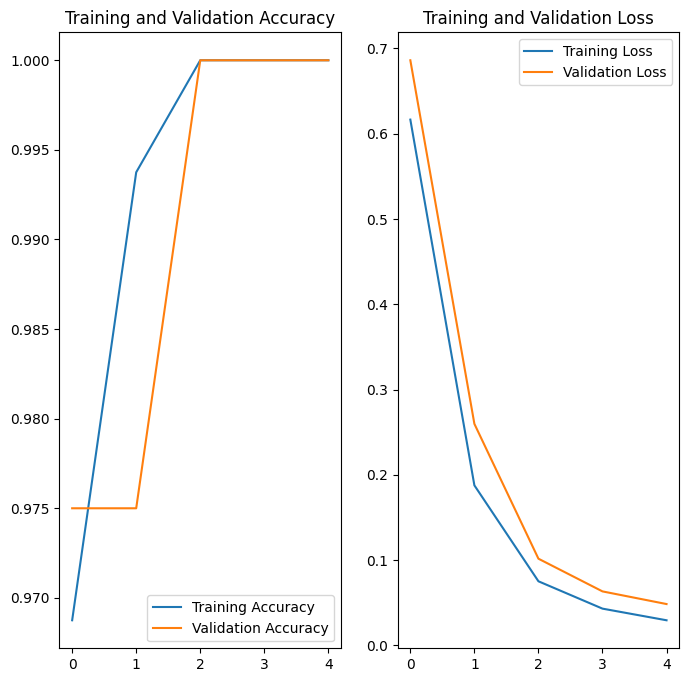

In [42]:
# train_loss_array,train_acc_array,val_loss_array,val_acc_array
acc = train_acc_list
val_acc = test_acc_list

loss = train_loss_list
val_loss = test_loss_list
epochs_range = range(epochs)

plt.figure(figsize=(8, 8))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()

## 统计指标分析

### 模型验证集预测

In [43]:
predict_list = []
label_list = []
predict_pro_list = []
m_softmax = nn.Softmax(dim=1)
for x_img,x_img_clip, x_text,x_text_clip, x_vec,  y in test_dl:
  x_img,x_img_clip, x_text,x_text_clip,x_vec,  y = x_img.to(device),x_img_clip.to(device),x_text.to(device),x_text_clip.to(device), x_vec.to(device), y.to(device)

  # Compute prediction error
  # print(x_img.shape,x_text.shape)
  predict_score = big_model(x_img,x_img_clip, x_text,x_text_clip, x_vec)
  # predict_score = big_model(b_img,b_text)
  predict_pro = m_softmax(predict_score)

  predict_label = np.argmax(predict_score.detach().cpu().numpy(),axis=1)

  predict_pro_list.append(predict_pro.detach().cpu().numpy())
  predict_list.append(predict_label)
  label_list.append(y.detach().cpu().numpy())

predict_pro_array = np.vstack(predict_pro_list)[:,1]
predict_array = np.hstack(predict_list)
label_array = np.hstack(label_list)
predict_pro_array[:5],predict_array[:5],label_array[:5]

(array([0.0101197 , 0.01166033, 0.8872669 , 0.01797273, 0.9747072 ],
       dtype=float32),
 array([3, 2, 1, 2, 1]),
 array([3, 2, 1, 2, 1]))

In [44]:
np.unique(predict_array)

array([0, 1, 2, 3])

In [45]:
len(np.unique(label_array))

4

### 分类报告

In [46]:
from sklearn.metrics import classification_report,confusion_matrix
print(classification_report(label_array, predict_array,digits=3))

              precision    recall  f1-score   support

           0      1.000     1.000     1.000         9
           1      1.000     1.000     1.000        11
           2      1.000     1.000     1.000        10
           3      1.000     1.000     1.000        10

    accuracy                          1.000        40
   macro avg      1.000     1.000     1.000        40
weighted avg      1.000     1.000     1.000        40



### 混淆矩阵

In [47]:
from sklearn.metrics import confusion_matrix
cnf_matrix = confusion_matrix(label_array, predict_array)
cnf_matrix

array([[ 9,  0,  0,  0],
       [ 0, 11,  0,  0],
       [ 0,  0, 10,  0],
       [ 0,  0,  0, 10]])

<Axes: >

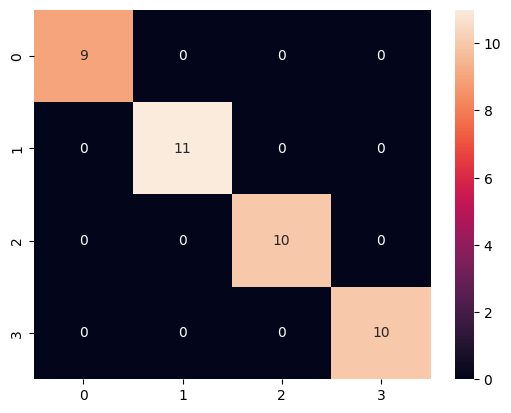

In [48]:
sns.heatmap(cnf_matrix, annot=True, fmt='g')

<Axes: >

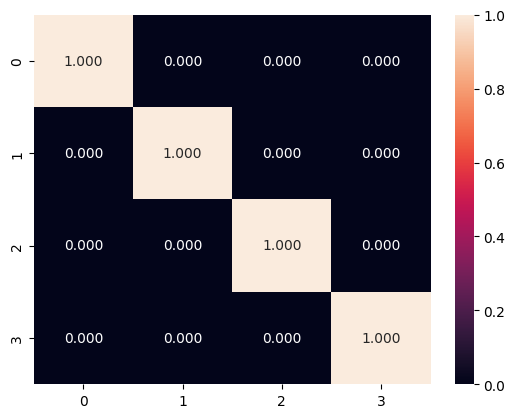

In [49]:
cm_normalized = cnf_matrix.astype('float') / cnf_matrix.sum(axis=1)[:, np.newaxis]
sns.heatmap(cm_normalized, annot=True, fmt='.3f')